# 📊 Сравнение алгоритмов поиска пути

В этом ноутбуке проводится экспериментальное сравнение алгоритмов поиска пути на случайно генерируемых гауссовых полях.

## Описание проекта

### 🎯 Цель исследования

Сравнить следующие алгоритмы:

(На сетке и графе):
- A* 
- Дейкстра
- Жадный (Greedy)

(Непрерывные):
- RRT
- RRT*

по следующим метрикам:

- время выполнения
- количество посещённых и обработанных узлов
- длина найденного пути (евклидова и пиксельная)
- успешность нахождения пути
- максимальные углы в пути (вбок и продольный)
- минимальные расстояния до препятсвия (евклидово и пиксельное)

### 🧪 Методология

Для каждого запуска:

1. Генерируется поле фиксированного размера (1000x1000) с гаусами с случайными параметрами в заданых диапозонах.
2. Запускаются все алгоритмы на одной и той же карте.
3. Метрики записываются в CSV файл.
4. Максимально допустимые углы вперед/назад и вбок = 50 градусам
5. Всего 100 запусков каждого алгоритма

#### 📌 Важно

Все алгоритмы сравниваются **на одинаковых входных данных**, что позволяет делать корректные выводы о производительности и качестве решений.

### Задачи исследования

1. Загрузить библиотеки и таблицу
2. Небольшая очистка/подготовка данных
3. Базовая статистика
- Вывод

## Ход исследования

### 1) Загрузка библиотек и таблицы

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# путь к CSV
path = "../var/metrics/pathCommands.csv"

df = pd.read_csv(path)

df.head()

,environment,algorithmName,executionTimeMs,pathNodes,expandedNodes,euclideanLength,pixelLength,pathFound,minObstacleDistance,minObstacleDistancePixel,maxSideAngle,maxUpDownAngle
0,graph,A*,3.245200,23,393,1538.69,1339,1,2.0,2,43.1915,32.7897
1,graph,Dijkstra,6.449660,23,1027,1538.69,1339,1,2.0,2,43.1915,32.7897
2,graph,Greedy,0.199743,34,33,1664.93,1430,1,2.0,2,46.7966,35.5183
3,grid,A*,35.620800,212,6191,1442.29,1056,1,0.0,0,72.0054,48.7936
4,grid,Dijkstra,157.723000,212,35729,1442.29,1056,1,1.0,1,59.5984,73.9916


In [9]:
graph = df[df["environment"] == "graph"]
success = (
    graph.groupby("algorithmName")["pathFound"]
         .agg(["sum", "count", "mean"])
)

success["success_%"] = success["mean"] * 100
print(success)

               sum  count  mean  success_%
algorithmName                             
A*             100    100  1.00      100.0
Dijkstra       100    100  1.00      100.0
Greedy          68    100  0.68       68.0


In [10]:
grid = df[df["environment"] == "grid"]
success = (
    grid.groupby("algorithmName")["pathFound"]
         .agg(["sum", "count", "mean"])
)

success["success_%"] = success["mean"] * 100
print(success)

               sum  count  mean  success_%
algorithmName                             
A*             100    100  1.00      100.0
Dijkstra       100    100  1.00      100.0
Greedy          99    100  0.99       99.0


In [11]:
continuous = df[df["environment"] == "continuous"]
success = (
    continuous.groupby("algorithmName")["pathFound"]
         .agg(["sum", "count", "mean"])
)

success["success_%"] = success["mean"] * 100
print(success)

               sum  count  mean  success_%
algorithmName                             
RRT            100    100  1.00      100.0
RRT*            95    100  0.95       95.0


### 2) Небольшая очистка/подготовка

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   environment               800 non-null    object 
 1   algorithmName             800 non-null    object 
 2   executionTimeMs           800 non-null    float64
 3   pathNodes                 800 non-null    int64  
 4   expandedNodes             800 non-null    int64  
 5   euclideanLength           800 non-null    float64
 6   pixelLength               800 non-null    int64  
 7   pathFound                 800 non-null    int64  
 8   minObstacleDistance       800 non-null    float64
 9   minObstacleDistancePixel  800 non-null    int64  
 10  maxSideAngle              800 non-null    float64
 11  maxUpDownAngle            800 non-null    float64
dtypes: float64(5), int64(5), object(2)
memory usage: 75.1+ KB


In [13]:
# приводим типы (на всякий случай)
df["executionTimeMs"] = df["executionTimeMs"].astype(float)
df["expandedNodes"] = df["expandedNodes"].astype(int)
df["pathNodes"] = df["pathNodes"].astype(int)
df["pathFound"] = df["pathFound"].astype(int)

df["euclideanLength"] = df["euclideanLength"].astype(float)
df["pixelLength"] = df["pixelLength"].astype(int)

df["minObstacleDistance"] = df["minObstacleDistance"].astype(float)
df["minObstacleDistancePixel"] = df["minObstacleDistancePixel"].astype(int)
df["maxSideAngle"] = df["maxSideAngle"].astype(float)
df["maxUpDownAngle"] = df["maxUpDownAngle"].astype(float)

In [14]:
# разделяем по алгоритмам
astar_graph = graph[graph["algorithmName"] == "A*"].reset_index(drop=True)
dijkstra_graph = graph[graph["algorithmName"] == "Dijkstra"].reset_index(drop=True)
greedy_graph = graph[graph["algorithmName"] == "Greedy"].reset_index(drop=True)

astar_grid = grid[grid["algorithmName"] == "A*"].reset_index(drop=True)
dijkstra_grid = grid[grid["algorithmName"] == "Dijkstra"].reset_index(drop=True)
greedy_grid = grid[grid["algorithmName"] == "Greedy"].reset_index(drop=True)

rrt = continuous[continuous["algorithmName"] == "RRT"].reset_index(drop=True)
rrt_star = continuous[continuous["algorithmName"] == "RRT*"].reset_index(drop=True)
# проверяем что строки совпадают по run-логике
n = min(len(astar_graph), len(dijkstra_graph), len(greedy_graph),
        len(astar_grid), len(dijkstra_grid), len(greedy_grid),
        len(rrt), len(rrt_star))

astar_graph = astar_graph.iloc[:n]
dijkstra_graph = dijkstra_graph.iloc[:n]
greedy_graph = greedy_graph.iloc[:n]

astar_grid = astar_grid.iloc[:n]
dijkstra_grid = dijkstra_grid.iloc[:n]
greedy_grid = greedy_grid.iloc[:n]

rrt = rrt.iloc[:n]
rrt_star = rrt_star.iloc[:n]

In [15]:
mask = (
    (astar_graph["pathFound"] == 1) & (dijkstra_graph["pathFound"] == 1) & (greedy_graph["pathFound"] == 1) &
    (astar_grid["pathFound"] == 1) & (dijkstra_grid["pathFound"] == 1) & (greedy_grid["pathFound"] == 1) &
    (rrt["pathFound"] == 1) & (rrt_star["pathFound"] == 1)
)

astar_graph = astar_graph[mask].reset_index(drop=True)
dijkstra_graph = dijkstra_graph[mask].reset_index(drop=True)
greedy_graph = greedy_graph[mask].reset_index(drop=True)

astar_grid = astar_grid[mask].reset_index(drop=True)
dijkstra_grid = dijkstra_grid[mask].reset_index(drop=True)
greedy_grid = greedy_grid[mask].reset_index(drop=True)

rrt = rrt[mask].reset_index(drop=True)
rrt_star = rrt_star[mask].reset_index(drop=True)

In [21]:
pathFind_ok = pd.concat([astar_graph, dijkstra_graph, greedy_graph,
                         astar_grid, dijkstra_grid, greedy_grid,
                         rrt, rrt_star], ignore_index=True)
pathFind_ok.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   environment               504 non-null    object 
 1   algorithmName             504 non-null    object 
 2   executionTimeMs           504 non-null    float64
 3   pathNodes                 504 non-null    int64  
 4   expandedNodes             504 non-null    int64  
 5   euclideanLength           504 non-null    float64
 6   pixelLength               504 non-null    int64  
 7   pathFound                 504 non-null    int64  
 8   minObstacleDistance       504 non-null    float64
 9   minObstacleDistancePixel  504 non-null    int64  
 10  maxSideAngle              504 non-null    float64
 11  maxUpDownAngle            504 non-null    float64
dtypes: float64(5), int64(5), object(2)
memory usage: 47.4+ KB


### 3) Базовая статистика


=========== executionTimeMs ===========
                               mean    median     std       min       max
environment algorithmName                                                
continuous  RRT              11.708     7.774  13.765     2.964    92.040
            RRT*           3593.040  3571.340  73.052  3512.710  3927.410
graph       A*                3.461     3.470   0.919     0.512     5.722
            Dijkstra          6.578     6.523   0.352     6.222     8.748
            Greedy            0.231     0.228   0.033     0.158     0.294
grid        A*               25.670    26.050   7.217     8.944    38.853
            Dijkstra        159.515   158.244   3.962   156.665   181.677
            Greedy            1.652     1.645   0.050     1.565     1.859


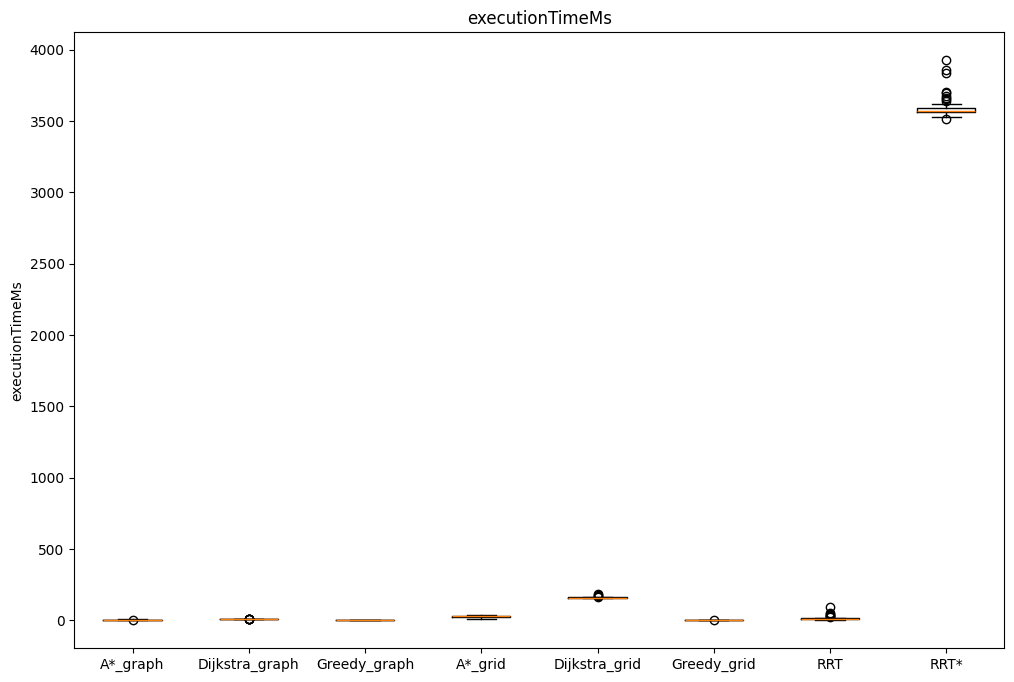


=========== expandedNodes ===========
                                mean   median       std    min    max
environment algorithmName                                            
continuous  RRT              316.317    213.0   338.362     88   2105
            RRT*           18268.429  18267.0    63.401  18156  18469
graph       A*               418.381    427.0   115.190     41    727
            Dijkstra        1027.238   1027.0    22.270    945   1076
            Greedy            41.476     40.0     8.183     24     58
grid        A*              4484.397   4543.0  1257.214   1504   6571
            Dijkstra       35893.143  35890.0    94.608  35672  36061
            Greedy           215.000    214.0     6.834    204    247


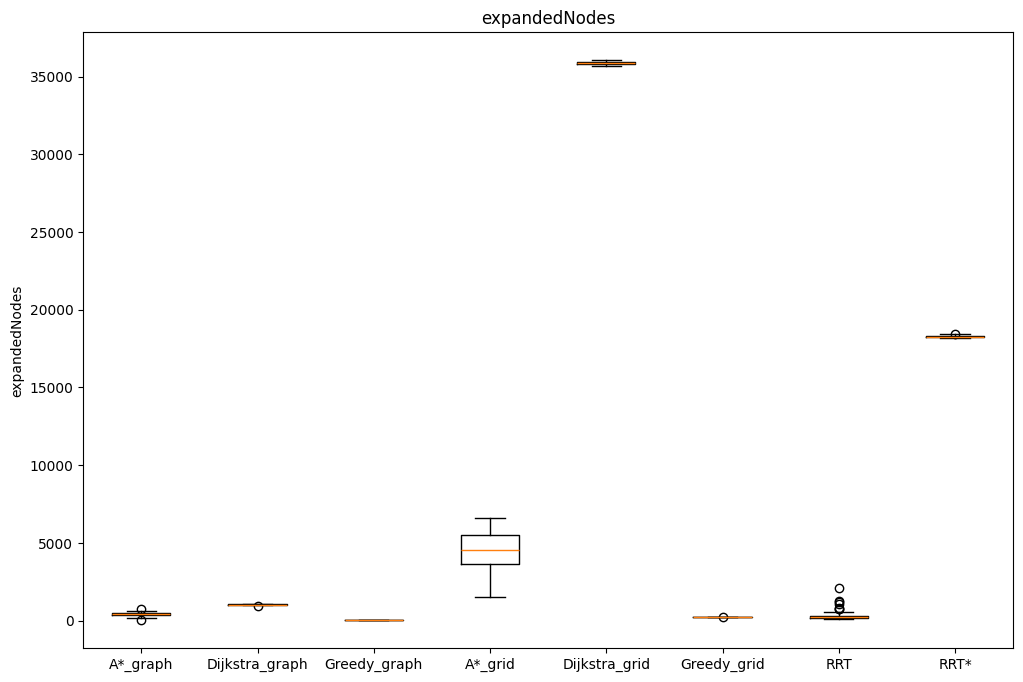


=========== pathNodes ===========
                              mean  median     std  min  max
environment algorithmName                                   
continuous  RRT             45.413    45.0   2.519   41   55
            RRT*            66.968    67.0   8.980   44   85
graph       A*              44.603    46.0  11.360    8   66
            Dijkstra        44.603    46.0  11.360    8   66
            Greedy          42.476    41.0   8.183   25   59
grid        A*             209.540   209.0   2.235  205  214
            Dijkstra       209.540   209.0   2.235  205  214
            Greedy         216.000   215.0   6.834  205  248


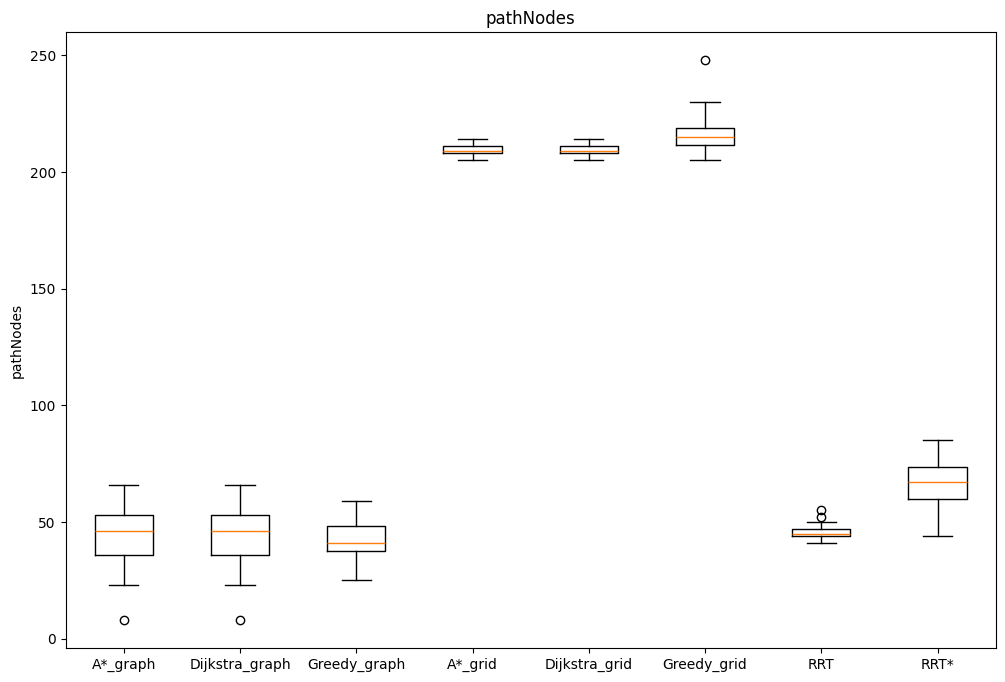


=========== euclideanLength ===========
                               mean   median      std      min      max
environment algorithmName                                              
continuous  RRT            1711.072  1699.97   99.483  1559.19  2098.62
            RRT*           1433.657  1433.46    5.968  1419.49  1446.71
graph       A*             1560.743  1561.11   43.026  1426.74  1714.24
            Dijkstra       1560.743  1561.11   43.026  1426.74  1714.24
            Greedy         1799.936  1757.12  165.624  1536.97  2250.81
grid        A*             1435.083  1433.50    6.545  1421.79  1448.15
            Dijkstra       1435.083  1433.50    6.545  1421.79  1448.15
            Greedy         1474.125  1467.65   37.960  1421.79  1676.14


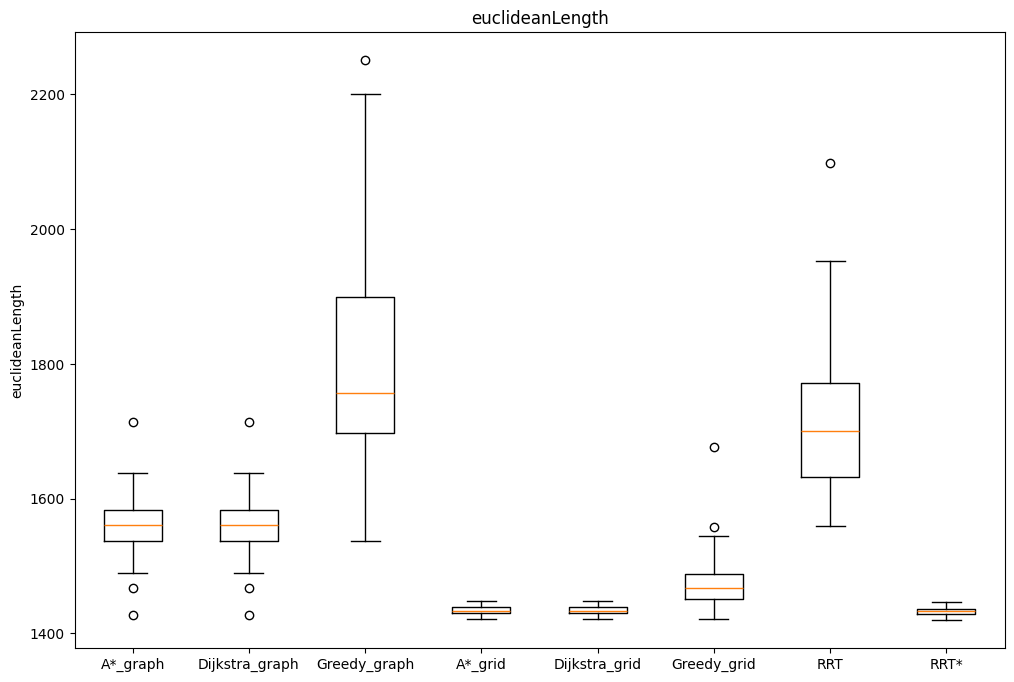


=========== pixelLength ===========
                               mean  median      std   min   max
environment algorithmName                                       
continuous  RRT            1473.222  1463.0  109.441  1284  1934
            RRT*           1142.889  1140.0   19.196  1086  1180
graph       A*             1355.778  1365.0   77.190  1102  1581
            Dijkstra       1355.778  1365.0   77.190  1102  1581
            Greedy         1626.444  1607.0  196.573  1276  2107
grid        A*             1043.698  1041.0   11.174  1021  1066
            Dijkstra       1043.698  1041.0   11.174  1021  1066
            Greedy         1076.000  1071.0   34.172  1021  1236


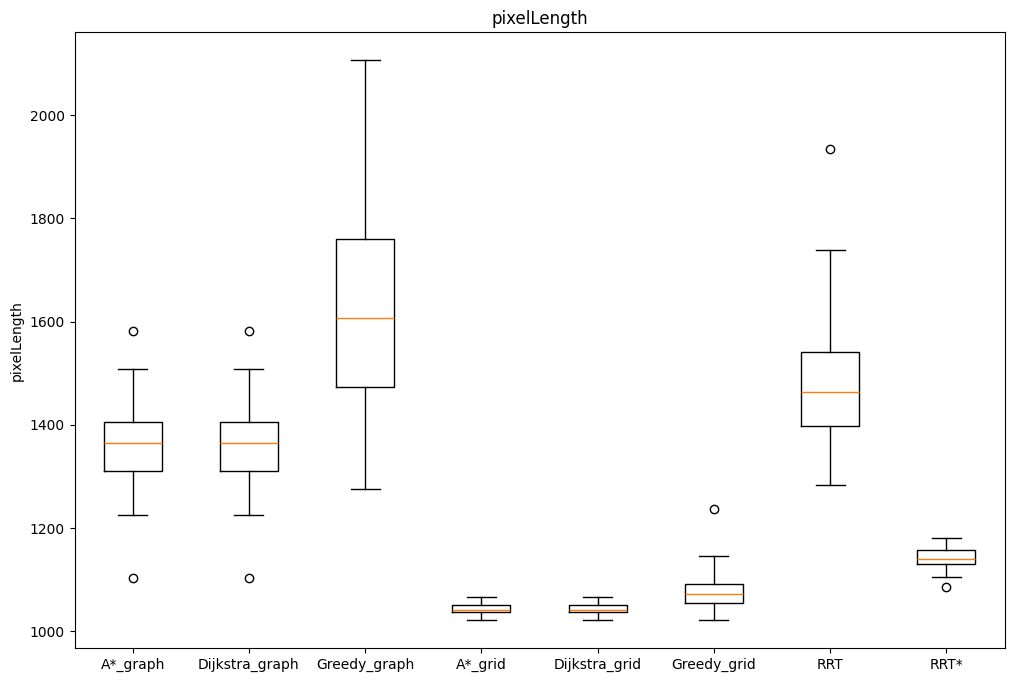


=========== minObstacleDistance ===========
                            mean  median    std    min    max
environment algorithmName                                    
continuous  RRT            2.000   2.000  0.000  2.000  2.000
            RRT*           2.000   2.000  0.000  2.000  2.000
graph       A*             1.823   2.000  0.271  1.414  2.000
            Dijkstra       1.823   2.000  0.271  1.414  2.000
            Greedy         1.795   2.000  0.282  1.414  2.000
grid        A*             1.025   1.000  0.418  0.000  2.000
            Dijkstra       1.347   1.414  0.488  0.000  2.000
            Greedy         0.677   1.000  0.510  0.000  1.414


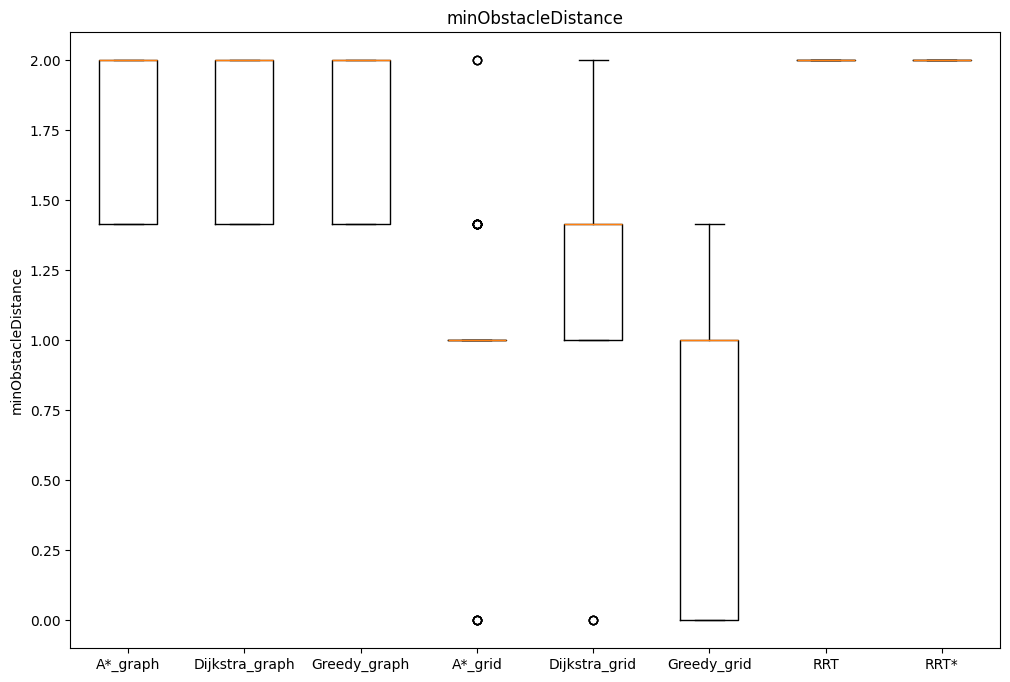


=========== minObstacleDistancePixel ===========
                            mean  median    std  min  max
environment algorithmName                                
continuous  RRT            2.000     2.0  0.000    2    2
            RRT*           2.000     2.0  0.000    2    2
graph       A*             2.000     2.0  0.000    2    2
            Dijkstra       2.000     2.0  0.000    2    2
            Greedy         2.000     2.0  0.000    2    2
grid        A*             1.127     1.0  0.553    0    2
            Dijkstra       1.635     2.0  0.604    0    2
            Greedy         0.714     1.0  0.580    0    2


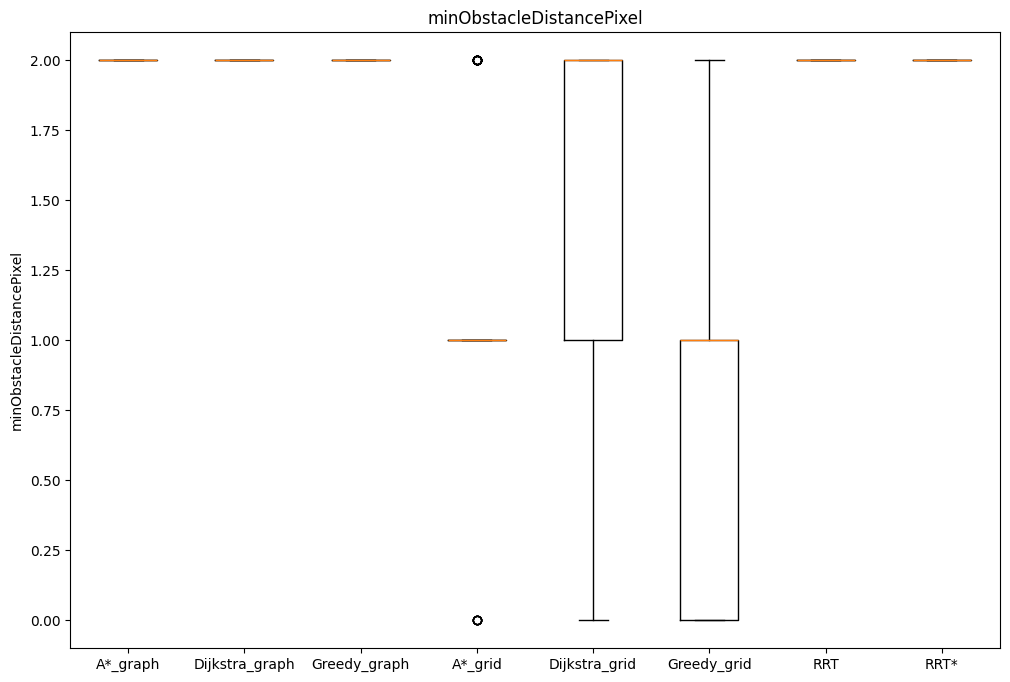


=========== maxSideAngle ===========
                             mean  median    std     min     max
environment algorithmName                                       
continuous  RRT            48.379  48.777  1.304  45.157  49.992
            RRT*           48.032  48.914  2.378  38.914  49.968
graph       A*             44.085  45.268  4.758  31.147  49.969
            Dijkstra       44.085  45.268  4.758  31.147  49.969
            Greedy         45.429  46.181  3.846  32.166  57.209
grid        A*             63.218  63.940  4.790  53.694  75.954
            Dijkstra       58.115  57.049  7.465  42.322  73.772
            Greedy         67.085  67.552  3.872  58.071  75.770


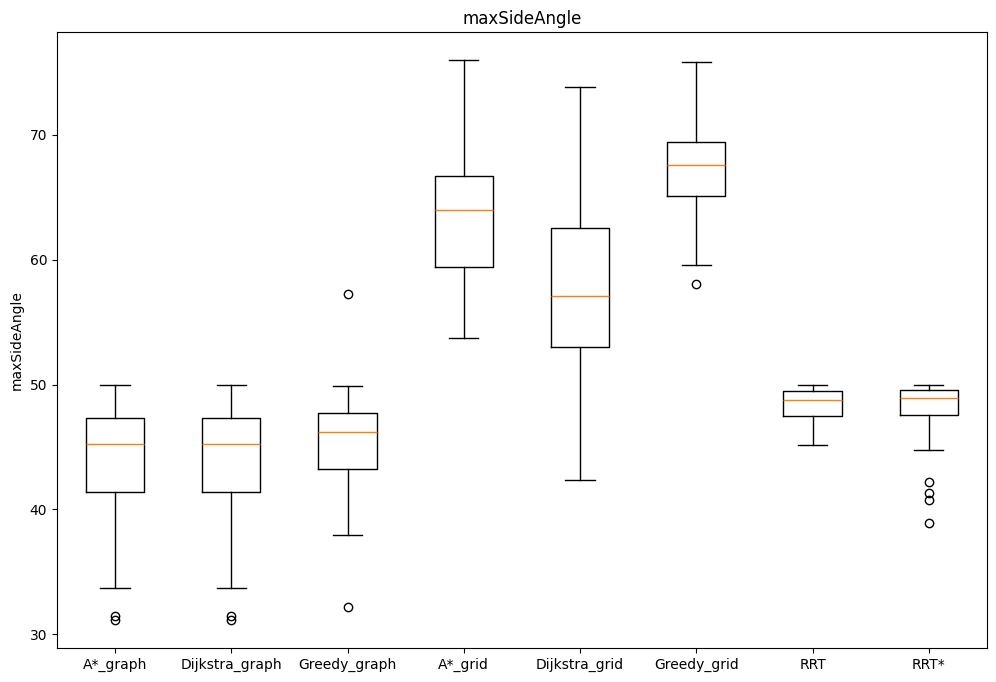


=========== maxUpDownAngle ===========
                             mean  median     std     min     max
environment algorithmName                                        
continuous  RRT            38.941  39.189   5.861  26.602  48.798
            RRT*           33.290  32.952   5.330  20.506  45.532
graph       A*             33.818  33.511   6.824  16.694  48.397
            Dijkstra       33.818  33.511   6.824  16.694  48.397
            Greedy         36.668  36.072   6.239  22.102  57.107
grid        A*             50.099  49.979   7.972  32.854  70.036
            Dijkstra       44.920  42.968  10.493  22.668  73.992
            Greedy         59.920  59.376   6.160  45.304  74.008


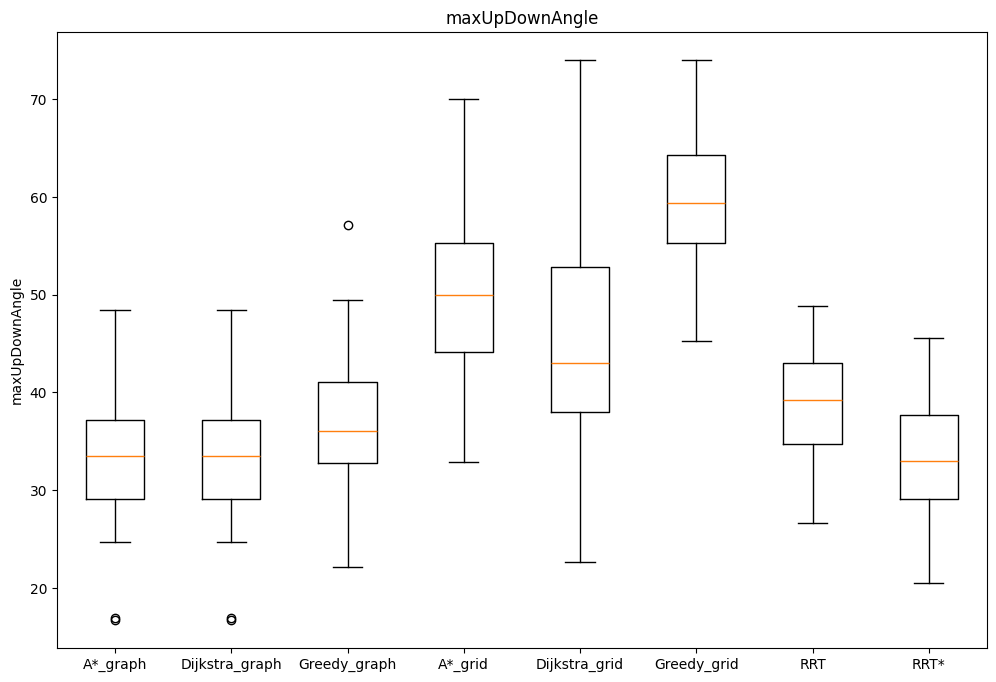

In [20]:
metrics = [
    "executionTimeMs",
    "expandedNodes",
    "pathNodes",
    "euclideanLength",
    "pixelLength",
    "minObstacleDistance",
    "minObstacleDistancePixel",
    "maxSideAngle",
    "maxUpDownAngle"
]

for metric in metrics:
    print(f"\n\033[1m=========== {metric} ===========\033[0m")

    summary = (
        pathFind_ok.groupby(["environment", "algorithmName"])[metric]
          .agg(["mean", "median", "std", "min", "max"])
          .round(3)
    )

    print(summary)
    plt.figure(figsize=(12, 8))

    plt.boxplot([
        astar_graph[metric], dijkstra_graph[metric], greedy_graph[metric],
        astar_grid[metric], dijkstra_grid[metric], greedy_grid[metric],
        rrt[metric], rrt_star[metric]
    ], tick_labels=["A*_graph", "Dijkstra_graph", "Greedy_graph",
                    "A*_grid", "Dijkstra_grid", "Greedy_grid",
                    "RRT", "RRT*"
                   ]
               )

    plt.title(metric)
    plt.ylabel(metric)

    plt.show()

#### Вывод

Из 100 сгенерированных карт в итоговую статистику вошли 63 запуска, в которых все алгоритмы успешно нашли путь. Случаи, где хотя бы один алгоритм не смог построить маршрут, были исключены из сравнения.

Среди классических методов поиска кратчайшего пути A* показал лучшие результаты, поэтому дальнейшее сравнение проводилось именно с ним.

A* на графе Вороного оказался наиболее быстрым детерминированным алгоритмом: среднее время составило 3.46 мс, тогда как на сетке — 25.67 мс. Кроме того, графовая реализация требовала обработки примерно 418 вершин, тогда как сеточная — около 4484, что объясняет почти восьмикратную разницу по времени выполнения.

RRT строил маршрут значительно быстрее, чем RRT* (11.7 мс против 3593 мс), однако получаемые пути были заметно длиннее (в среднем 1711 против 1434 условных единиц). Это связано с отсутствием оптимизации дерева после добавления новых вершин.

RRT*, напротив, обеспечивал длину пути, практически совпадающую с оптимальным маршрутом, найденным алгоритмом A* на сетке (1433.7 против 1435.1 условных единиц). Таким образом, RRT* способен находить практически оптимальные траектории в непрерывном пространстве, однако достигается это ценой значительно больших вычислительных затрат.

В результате можно сделать вывод, что A* на графе Вороного является наиболее эффективным решением по соотношению качества маршрута и скорости работы. RRT подходит для быстрого получения допустимого пути в непрерывной среде, а RRT* — для случаев, когда требуется близкая к оптимальной траектория и допустимо существенно большее время вычислений.